### **Dataset:**

Kids stories URLs:

https://www.eqraa.info/qss-llqraah

https://www.for9a.com/learn/7-%D9%82%D8%B5%D8%B5-%D9%85%D9%86-%D8%A3%D8%AC%D9%85%D9%84-%D9%82%D8%B5%D8%B5-%D8%A7%D9%84%D8%A3%D8%B7%D9%81%D8%A7%D9%84-%D9%84%D8%AA%D8%B1%D9%88%D9%8A%D9%87%D8%A7-%D9%84%D9%87%D9%85-%D9%82%D8%A8%D9%84-%D8%A7%D9%84%D9%86%D9%88%D9%85

https://www.kaggle.com/datasets/tahaalselwii/arabic-short-stories-collection-5k?select=arabic_stories.csv


Web Scraper:

https://ultimatewebscraper.com/tools/website-to-text


poems_ahmed_shawki:

https://www.kaggle.com/datasets/ahmedgamal12/arabic-poetry-for-ahmed-skawki


### **GPT from Scratch**

Data -> Tokenizer -> Model -> Pretraining -> Fine-tuning -> Evaluation

## **Hyperparameters**

vocab_size = 8000

layers = 4

heads = 4

epochs = 2

lr = 3e-4

d_model = 256

dropout = 0.1

**Step 1: Collect Pretraining Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/gpt-from-scratch/

artifacts    data  gpt-from-scratch-Arabic  results
checkpoints  demo  requirements.txt	    src


In [ ]:
import os

project_root = "/content/drive/MyDrive/gpt-from-scratch"
os.makedirs(project_root, exist_ok=True)

folders = [
    "data/pretrain/raw",
    "data/pretrain/cleaned",
    "data/finetune",
    "src/model",
    "src/tokenizer",
    "src/training",
    "src/evaluation",
    "checkpoints",
    "demo",
    "results"
]

for f in folders:
    os.makedirs(os.path.join(project_root, f), exist_ok=True)

In [ ]:
open("/content/drive/MyDrive/gpt-from-scratch/src/__init__.py", "a").close()
open("/content/drive/MyDrive/gpt-from-scratch/src/model/__init__.py", "a").close()

In [ ]:
import os
import re
from pathlib import Path

raw_dir = Path("/content/drive/MyDrive/gpt-from-scratch/data/pretrain/raw")
clean_dir = Path("/content/drive/MyDrive/gpt-from-scratch/data/pretrain/cleaned")
clean_dir.mkdir(parents=True, exist_ok=True)

def clean_arabic_text(text: str) -> str:
    text = text.replace("ـ", "")  # remove tatweel
    text = re.sub(r"<[^>]+>", " ", text)  # remove html tags
    text = re.sub(r"[ \t]+", " ", text)   # collapse spaces but keep newlines
    text = re.sub(r"\n\s*\n+", "\n\n", text)  # normalize paragraph breaks
    return text.strip()

for file in raw_dir.glob("*.txt"):
    text = file.read_text(encoding="utf-8", errors="ignore")
    cleaned = clean_arabic_text(text)
    out_path = clean_dir / file.name
    out_path.write_text(cleaned, encoding="utf-8")

In [ ]:
from pathlib import Path

clean_dir = Path("/content/drive/MyDrive/gpt-from-scratch/data/pretrain/cleaned")
output_file = Path("/content/drive/MyDrive/gpt-from-scratch/data/pretrain/data.txt")

all_texts = []
for file in sorted(clean_dir.glob("*.txt")):
    txt = file.read_text(encoding="utf-8").strip()
    if txt:
        all_texts.append("<bos>\n" + txt + "\n<eos>")

output_file.write_text("\n\n".join(all_texts), encoding="utf-8")
print(f"Saved merged corpus to: {output_file}")

Saved merged corpus to: /content/drive/MyDrive/gpt-from-scratch/data/pretrain/data.txt


In [ ]:
# print first lines
with open("/content/drive/MyDrive/gpt-from-scratch/data/pretrain/data.txt","r",encoding="utf-8") as f:
    for i in range(20):
        print(f.readline())

<bos>

في قرية صغيرة تحيط بها أشجار النخيل العالية، كان يعيش طفل اسمه سامي. كان سامي في الثامنة من عمره، وكان ينتظر شهر رمضان كل عام بشوقٍ كبير. لكنه هذا العام كان مختلفًا… لأنه قرر أن يصوم لأول مرة!



بداية التحدي



في أول يوم من رمضان، استيقظ سامي قبل الفجر على صوت أمه وهي تنادي بلطف:



"سامي… حان وقت السحور."



فتح سامي عينيه بصعوبة، وكان النعاس لا يزال يحيط به مثل غيمة صغيرة. جلس على الطاولة وأكل التمر وشرب الحليب. ابتسمت له أمه وقالت:



"الصيام ليس فقط عن الجوع يا سامي… إنه تدريبٌ للقلب أيضاً."



لم يفهم سامي تماماً ما تقصده، لكنه هزّ رأسه بحماس.



صديق غير متوقع



مع مرور ساعات الصباح، بدأ سامي يشعر بالجوع. جلس في الحديقة تحت شجرة نخيل، وفجأة سمع صوتاً خفيفاً:



"هل هذه أول مرة تصوم؟"



Check the file size and lines

In [ ]:
file_path = "/content/drive/MyDrive/gpt-from-scratch/data/pretrain/data.txt" # min 1000 lines

with open(file_path, "r", encoding="utf-8") as f:
    lines = sum(1 for _ in f)

print("Number of lines:", lines)

Number of lines: 425615


In [ ]:
import os

file_path = "/content/drive/MyDrive/gpt-from-scratch/data/pretrain/data.txt" # min 2 MB

size_bytes = os.path.getsize(file_path)
size_mb = size_bytes / (1024 * 1024)

print(f"File size: {size_mb:.2f} MB")

File size: 20.87 MB


**Step 2: Tokenizer**

In [ ]:
!pip install sentencepiece

Train the tokenizer

In [ ]:
import os
import sentencepiece as spm

project_root = "/content/drive/MyDrive/gpt-from-scratch"

input_file = f"{project_root}/data/pretrain/data.txt"

model_dir = f"{project_root}/src/tokenizer"
os.makedirs(model_dir, exist_ok=True)

spm.SentencePieceTrainer.train(
    input=input_file,
    model_prefix=f"{model_dir}/arabic_bpe",  # <-- saves in model folder
    vocab_size=8000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3
)

print("Tokenizer saved inside src/tokenizer/")

Tokenizer saved inside src/tokenizer/


Test the tokenizer

In [ ]:
import sentencepiece as spm

tokenizer_path = "/content/drive/MyDrive/gpt-from-scratch/src/tokenizer/arabic_bpe.model"

sp = spm.SentencePieceProcessor()
sp.load(tokenizer_path)

print("Tokenizer loaded successfully")

Tokenizer loaded successfully


In [ ]:
import sentencepiece as spm

sp = spm.SentencePieceProcessor()
sp.load("/content/drive/MyDrive/gpt-from-scratch/src/tokenizer/arabic_bpe.model")

sample_text = "كان يا ما كان في قديم الزمان."
ids = sp.encode(sample_text, out_type=int)
tokens = sp.encode(sample_text, out_type=str)
decoded = sp.decode(ids)

print("Original:", sample_text)
print("Token IDs:", ids)
print("Tokens:", tokens)
print("Decoded:", decoded)

Original: كان يا ما كان في قديم الزمان.
Token IDs: [93, 501, 42, 93, 104, 1758, 6201, 7896]
Tokens: ['▁كان', '▁يا', '▁ما', '▁كان', '▁في', '▁قديم', '▁الزمان', '.']
Decoded: كان يا ما كان في قديم الزمان.


In [ ]:
#Encode the whole corpus
from pathlib import Path
import pickle

project_root = "/content/drive/MyDrive/gpt-from-scratch"
corpus_path = Path(project_root) / "data/pretrain/data.txt"

text = corpus_path.read_text(encoding="utf-8")
train_ids = sp.encode(text, out_type=int)

artifacts_dir = Path(project_root) / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

with open(artifacts_dir / "train_ids.pkl", "wb") as f:
    pickle.dump(train_ids, f)

print("Number of tokens:", len(train_ids))
print("Saved token IDs to:", artifacts_dir / "train_ids.pkl")

Number of tokens: 4845670
Saved token IDs to: /content/drive/MyDrive/gpt-from-scratch/artifacts/train_ids.pkl


In [ ]:
# Save  validation split
split_idx = int(0.9 * len(train_ids))
train_tokens = train_ids[:split_idx]
valid_tokens = train_ids[split_idx:]

with open(artifacts_dir / "train_ids.pkl", "wb") as f:
    pickle.dump(train_tokens, f)

with open(artifacts_dir / "valid_ids.pkl", "wb") as f:
    pickle.dump(valid_tokens, f)

print("Train tokens:", len(train_tokens))
print("Valid tokens:", len(valid_tokens))

Train tokens: 4361103
Valid tokens: 484567


In [ ]:
print("Vocabulary size:", sp.get_piece_size()) #Check vocabulary size

Vocabulary size: 8000


**Step 3: GPT Model**

In [ ]:
d_model = 256
num_heads = 4
max_seq_len = 128
dropout = 0.1

In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/gpt-from-scratch")

import torch
from src.model.gpt import GPT

model = GPT(
    vocab_size=8000,
    max_seq_len=128,
    d_model=256,
    num_heads=4,
    num_layers=4,
    dropout=0.1
)

x = torch.randint(0, 8000, (2, 16))   # batch=2, seq_len=16
targets = torch.randint(0, 8000, (2, 16))

logits, loss = model(x, targets)

print("Logits shape:", logits.shape)
print("Loss:", loss.item())

Logits shape: torch.Size([2, 16, 8000])
Loss: 8.996849060058594


In [ ]:
!ls /content/drive/MyDrive/gpt-from-scratch/src/training

finetune.py  pretrain.py


In [ ]:
!ls /content/drive/MyDrive/gpt-from-scratch/data/pretrain

cleaned  data.txt  raw


In [ ]:
!head /content/drive/MyDrive/gpt-from-scratch/data/pretrain/data.txt

<bos>
في قرية صغيرة تحيط بها أشجار النخيل العالية، كان يعيش طفل اسمه سامي. كان سامي في الثامنة من عمره، وكان ينتظر شهر رمضان كل عام بشوقٍ كبير. لكنه هذا العام كان مختلفًا… لأنه قرر أن يصوم لأول مرة!

بداية التحدي

في أول يوم من رمضان، استيقظ سامي قبل الفجر على صوت أمه وهي تنادي بلطف:

"سامي… حان وقت السحور."

فتح سامي عينيه بصعوبة، وكان النعاس لا يزال يحيط به مثل غيمة صغيرة. جلس على الطاولة وأكل التمر وشرب الحليب. ابتسمت له أمه وقالت:


**Step 4: Pretraining**

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
!python /content/drive/MyDrive/gpt-from-scratch/src/training/pretrain.py

Streaming output truncated to the last 5000 lines.
epoch 0 | step 107400 | loss 1.3469
epoch 0 | step 107500 | loss 1.6044
epoch 0 | step 107600 | loss 1.5738
epoch 0 | step 107700 | loss 1.3861
epoch 0 | step 107800 | loss 1.3163
epoch 0 | step 107900 | loss 1.7265
epoch 0 | step 108000 | loss 1.2639
epoch 0 | step 108100 | loss 1.4626
epoch 0 | step 108200 | loss 1.4468
epoch 0 | step 108300 | loss 1.6508
epoch 0 | step 108400 | loss 1.4086
epoch 0 | step 108500 | loss 1.4712
epoch 0 | step 108600 | loss 1.5362
epoch 0 | step 108700 | loss 1.6897
epoch 0 | step 108800 | loss 1.4839
epoch 0 | step 108900 | loss 1.7018
epoch 0 | step 109000 | loss 1.2484
epoch 0 | step 109100 | loss 1.4803
epoch 0 | step 109200 | loss 1.3311
epoch 0 | step 109300 | loss 1.5587
epoch 0 | step 109400 | loss 1.3691
epoch 0 | step 109500 | loss 1.4978
epoch 0 | step 109600 | loss 1.2609
epoch 0 | step 109700 | loss 1.4676
epoch 0 | step 109800 | loss 1.5359
epoch 0 | step 109900 | loss 1.4213
epoch 0 | ste

**Step 5: Fine-tuning**

In [ ]:
!ls /content/drive/MyDrive/gpt-from-scratch/src/training

finetune.py  pretrain.py


In [ ]:
# Add more examples for file
import json
import os

project_root = "/content/drive/MyDrive/gpt-from-scratch"
os.makedirs(f"{project_root}/data/finetune", exist_ok=True)

story_titles = [
    "طفل وجد مفتاحاً غامضاً",
    "قطة تبحث عن منزل",
    "باب سري في المدرسة",
    "رحلة في الصحراء",
    "مدينة تحت البحر",
    "صبي وجد خريطة قديمة",
    "طائر يتكلم",
    "مكتبة مليئة بالأسرار",
    "فتاة تبحث عن نجم ضائع",
    "قرية يزورها القمر"
]

openings = [
    "في صباح هادئ، خرج الطفل من منزله وهو لا يعلم أن ذلك اليوم سيغير حياته.",
    "في آخر الزقاق القديم، كان هناك باب لا يفتحه أحد.",
    "عندما هبت الريح، سقطت ورقة صفراء أمام قدميه.",
    "في ليلة مقمرة، سمع صوتاً غريباً يأتي من بعيد.",
    "بينما كانت تمشي وحدها، لمحت شيئاً يلمع تحت الشجرة."
]

continuations = [
    "اقترب بحذر، ثم اكتشف أن المفتاح يفتح صندوقاً قديماً مليئاً بالرسائل.",
    "دخل المكان المظلم فوجد سلماً يقوده إلى غرفة لم ير مثلها من قبل.",
    "سمع همساً خافتاً يدعوه إلى متابعة الطريق دون خوف.",
    "وجد خريطة صغيرة تشير إلى بئر مهجور في أطراف القرية.",
    "بدأ قلبه يخفق بسرعة عندما رأى الضوء الأزرق يخرج من الشقوق."
]

endings = [
    "وفي النهاية عاد إلى بيته وهو يحمل سراً جميلاً لن ينساه أبداً.",
    "ومنذ ذلك اليوم أصبح أكثر شجاعة وحكمة من قبل.",
    "وهكذا بدأت أعظم مغامرة عرفتها القرية الصغيرة.",
    "وعندما طلعت الشمس، أدرك أن الخير كان ينتظره طوال الطريق.",
    "ثم ابتسم وعرف أن الأمل قد يقوده دائماً إلى بداية جديدة."
]

examples = []

# 1 story writing
for i in range(80):
    title = story_titles[i % len(story_titles)]
    opening = openings[i % len(openings)]
    continuation = continuations[i % len(continuations)]
    ending = endings[i % len(endings)]

    examples.append({
        "instruction": f"اكتب قصة قصيرة عن {title}.",
        "input": "",
        "output": f"{opening} {continuation} {ending}"
    })

# 2 story continuation
for i in range(60):
    opening = openings[i % len(openings)]
    continuation = continuations[(i + 1) % len(continuations)]
    ending = endings[(i + 2) % len(endings)]

    examples.append({
        "instruction": "أكمل القصة التالية.",
        "input": opening,
        "output": f"{continuation} {ending}"
    })

# 3 happy ending rewrite
for i in range(30):
    examples.append({
        "instruction": "غيّر نهاية القصة إلى نهاية سعيدة.",
        "input": "انتهت الرحلة بخوف شديد وعودة سريعة إلى المنزل دون اكتشاف السر.",
        "output": endings[i % len(endings)]
    })

# 4 summarization
for i in range(30):
    title = story_titles[i % len(story_titles)]

    examples.append({
        "instruction": "لخّص القصة التالية في سطر واحد.",
        "input": f"تحكي القصة عن {title} يمر بمغامرة مليئة بالغموض ثم يتعلم درساً مهماً عن الشجاعة والأمل.",
        "output": f"قصة قصيرة عن {title} يتعلم فيها البطل درساً عن الشجاعة."
    })

print("Total examples:", len(examples))

with open(f"{project_root}/data/finetune/sft_data.json", "w", encoding="utf-8") as f:
    json.dump(examples, f, ensure_ascii=False, indent=2)

print("SFT dataset saved successfully")

Total examples: 200
SFT dataset saved successfully


In [ ]:
!python /content/drive/MyDrive/gpt-from-scratch/src/training/finetune.py

Training device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Tokenizer loaded
SFT samples: 200
Encoded samples: 200
Dataset size: 200
Loaded pretrained checkpoint
Model parameters: 5240320
epoch 0 | step 0 | loss 12.5824
epoch 0 | step 20 | loss 3.7114

Epoch 0 complete
Average Loss: 5.9543
Perplexity: 385.40

Saved checkpoint: /content/drive/MyDrive/gpt-from-scratch/checkpoints/finetuned/gpt_finetuned_epoch_0.pt
epoch 1 | step 0 | loss 3.4693
epoch 1 | step 20 | loss 1.9124

Epoch 1 complete
Average Loss: 2.4413
Perplexity: 11.49

Saved checkpoint: /content/drive/MyDrive/gpt-from-scratch/checkpoints/finetuned/gpt_finetuned_epoch_1.pt

Generated fine-tuned text:

 ⁇  التعليمات: اكتب قصة قصيرة عن طفل وجد مفتاحاً غامضاً.  ⁇  المدخلات:  ⁇  الاستجابة: أضاء اليوم من الأيام، وقع أمام السعادة في الغابة. ثم ابتسم الاثنان أكثر يستحقمبراطور. ثم ابتسم السلام وهو يحمل جناه غريباً ينساب للنحل ّق إلى بئر أحلامه‪.‬‬ ‫ب ع د فت ر ة‪ ،‬ت و ف ي‬ ‫ا ل ر ح ل ة ‪ ،‬و ب دأ‬ ‫ي ست جي ب ل د و ر ه ‪.

In [ ]:
import sys
import torch
import sentencepiece as spm

sys.path.append("/content/drive/MyDrive/gpt-from-scratch")
from src.model.gpt import GPT

project_root = "/content/drive/MyDrive/gpt-from-scratch"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_path = f"{project_root}/src/tokenizer/arabic_bpe.model"
pretrained_ckpt = f"{project_root}/checkpoints/pretrained/gpt_epoch_1.pt"
finetuned_ckpt = f"{project_root}/checkpoints/finetuned/gpt_finetuned_epoch_1.pt"

sp = spm.SentencePieceProcessor()
sp.load(tokenizer_path)

def load_model(ckpt_path):
    model = GPT(
        vocab_size=8000,
        max_seq_len=128,
        d_model=256,
        num_heads=4,
        num_layers=4,
        dropout=0.1
    ).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model

pretrained_model = load_model(pretrained_ckpt)
finetuned_model = load_model(finetuned_ckpt)

def generate_text(model, prompt, max_new_tokens=80, temperature=0.9, top_k=40):
    ids = sp.encode(prompt, out_type=int)
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model.generate(
            x,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k
        )
    return sp.decode(out[0].tolist())

prompts = [
    "في ليلة باردة عند أطراف القرية",
    "كان الطفل يحمل في جيبه رسالة قديمة",
    "### التعليمات:\nاكتب قصة قصيرة عن باب سري في المدرسة.\n\n### المدخلات:\n\n\n### الاستجابة:\n"
]

for i, prompt in enumerate(prompts, 1):
    print("=" * 80)
    print(f"Prompt {i}: {prompt}\n")

    print("Pretrained:\n")
    print(generate_text(pretrained_model, prompt))
    print("\n" + "-" * 80 + "\n")

    print("Fine-tuned:\n")
    print(generate_text(finetuned_model, prompt))
    print("\n")

Prompt 1: في ليلة باردة عند أطراف القرية

Pretrained:

في ليلة باردة عند أطراف القرية من رأيدة المزيد عن أحمد شوقي أضف معلومة او شرح بين أقصى أغرى لك من أنت على مضجفه والنجم تختلي وما فتن الحظ تان وكل باب قبله وشغيتها فرح تهتث منه الفناء ووحيم وتحقي وإن ناحية فذاك لا يهز

--------------------------------------------------------------------------------

Fine-tuned:

في ليلة باردة عند أطراف القرية على الضف الوافعل اليهول لما رحل فيما رأى منه الجسام المزيد عن أحمد شوقي أضف معلومة او شرح رأى في الحديث فتى قد ارثى الجامع في غرساه صار في الب ح ر ت ح ت شفة المساورقاه وترى القلب كلما لاقى العهد أظل من مسعود الرح


Prompt 2: كان الطفل يحمل في جيبه رسالة قديمة

Pretrained:

كان الطفل يحمل في جيبه رسالة قديمة‬ ‫ورسلها‬ ‫‪.‬إلى مكان ي ُعتقد أن في عالم‬ ‫الأر ض‬ ‫ف ي أ ح د ا لأيا م‬ ‫ال م ش م س ة‪ ،‬كا ن‬ ‫هنا ك شا ب ي د ع ى‬ ‫عل ي ي عي ش ف ي‬ ‫ق ري ة ص غي ر ة ‪.‬‬ ‫كان علي شغوفًا‬ ‫ب ا ل ك ت

--------------------------------------------------------------------------------

Fine-tuned:

كان الطفل ي

**Step 6: Evaluation**

In [ ]:
import os

results_dir = "/content/drive/MyDrive/gpt-from-scratch/results/sample_generations"
os.makedirs(results_dir, exist_ok=True)

print("Folder ready:", results_dir)

Folder ready: /content/drive/MyDrive/gpt-from-scratch/results/sample_generations


In [ ]:
import sys
import torch
import sentencepiece as spm
import os

sys.path.append("/content/drive/MyDrive/gpt-from-scratch")

from src.model.gpt import GPT

device = "cuda" if torch.cuda.is_available() else "cpu"

project_root = "/content/drive/MyDrive/gpt-from-scratch"

tokenizer_path = f"{project_root}/src/tokenizer/arabic_bpe.model"
finetuned_ckpt = f"{project_root}/checkpoints/finetuned/gpt_finetuned_epoch_1.pt"

results_dir = f"{project_root}/results/sample_generations"
os.makedirs(results_dir, exist_ok=True)

# Load tokenizer
sp = spm.SentencePieceProcessor()
sp.load(tokenizer_path)

# Load model
model = GPT(
    vocab_size=8000,
    max_seq_len=128,
    d_model=256,
    num_heads=4,
    num_layers=4,
    dropout=0.1
).to(device)

model.load_state_dict(torch.load(finetuned_ckpt, map_location=device))
model.eval()

# Prompts to test
prompts = [
    "في ليلة باردة عند أطراف القرية",
    "كان الطفل يحمل في جيبه رسالة قديمة",
    "اكتب قصة قصيرة عن باب سري في المدرسة"
]

for i, prompt in enumerate(prompts):

    ids = sp.encode(prompt, out_type=int)
    x = torch.tensor(ids).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model.generate(x, max_new_tokens=80)

    text = sp.decode(output[0].tolist())

    # Save to file
    file_path = f"{results_dir}/sample_{i+1}.txt"

    with open(file_path, "w", encoding="utf-8") as f:
        f.write("PROMPT:\n")
        f.write(prompt + "\n\n")
        f.write("GENERATED:\n")
        f.write(text)

    print("Saved:", file_path)

Saved: /content/drive/MyDrive/gpt-from-scratch/results/sample_generations/sample_1.txt
Saved: /content/drive/MyDrive/gpt-from-scratch/results/sample_generations/sample_2.txt
Saved: /content/drive/MyDrive/gpt-from-scratch/results/sample_generations/sample_3.txt


In [ ]:
open("/content/drive/MyDrive/gpt-from-scratch/src/__init__.py","a").close()
open("/content/drive/MyDrive/gpt-from-scratch/src/evaluation/__init__.py","a").close()

In [ ]:
!ls /content/drive/MyDrive/gpt-from-scratch/src/evaluation

error_analysis.py  __init__.py	metrics.py  __pycache__


In [ ]:
import sys
import torch
import sentencepiece as spm

sys.path.append("/content/drive/MyDrive/gpt-from-scratch")

from src.model.gpt import GPT
from src.evaluation.metrics import generate_text, evaluate_generation_set
from src.evaluation.error_analysis import format_error_report

project_root = "/content/drive/MyDrive/gpt-from-scratch"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_path = f"{project_root}/src/tokenizer/arabic_bpe.model"
finetuned_ckpt = f"{project_root}/checkpoints/finetuned/gpt_finetuned_epoch_1.pt"

sp = spm.SentencePieceProcessor()
sp.load(tokenizer_path)

model = GPT(
    vocab_size=8000,
    max_seq_len=128,
    d_model=256,
    num_heads=4,
    num_layers=4,
    dropout=0.1
).to(device)

model.load_state_dict(torch.load(finetuned_ckpt, map_location=device))
model.eval()

prompts = [
    "في ليلة باردة عند أطراف القرية",
    "كان الطفل يحمل في جيبه رسالة قديمة",
    "اكتب قصة قصيرة عن باب سري في المدرسة"
]

samples = []
for prompt in prompts:
    output = generate_text(model, sp, prompt, device)
    samples.append({
        "prompt": prompt,
        "output": output
    })

results = evaluate_generation_set(samples)
for r in results:
    print(r["prompt"])
    print("instruction_score:", r["instruction_score"])
    print("repetition_score:", round(r["repetition_score"], 3))
    print(r["output"])
    print("=" * 80)

report = format_error_report(samples)
print(report)

في ليلة باردة عند أطراف القرية
instruction_score: 4
repetition_score: 0.122
في ليلة باردة عند أطراف القرية اليوم محّرجا من سامر إلى المدخار في ظل جديد.  ⁇  الاستجابة: عندما سمعت الشمس أصوات وهو ينجو من الخلف مصباح إلى الحديقة. هل كان المزيد عن أحمد شوقي أضف معلومة او شرح المزيد عن أحمد شوقي أضف معلومة او شرح سقطت ورقة صغيرة في الحديقة
كان الطفل يحمل في جيبه رسالة قديمة
instruction_score: 4
repetition_score: 0.0
كان الطفل يحمل في جيبه رسالة قديمة‬ ‫نا ف ذت ك ب ها ف ي‬ ‫م كتب ة غ ر فت ها‬ ‫ب عناي ة ‪ .‬كان ت تتل و‬ ‫أ ي ش يء م ن‬ ‫ا لأ ج ي ا ل وا لأ خ ر ى ‪،‬‬ ‫صا‬ ‫و ك ا ن ي ق رأ ش خ ً‬ ‫ما لل ق م ر‪،‬‬ ‫قد ً‬ ‫ي ح ك
اكتب قصة قصيرة عن باب سري في المدرسة
instruction_score: 4
repetition_score: 0.0
اكتب قصة قصيرة عن باب سري في المدرسة‬ ‫م ن ال قب ر‬ ‫‪ .‬ال ج مال ب لا ست ك شا ف ال غاب ة‬ ‫ف ي ق ري ة ص غي ر ة‬ ‫هنا ك‪ ،‬كان ت هنا ك‬ ‫أ س ط و ر ة تت ح د ث‬ ‫ع ن م صدر‬ ‫ال ص و ت‪ .‬كا ن‬ ‫ال ع ص ف و ر يب
Error Analysis Report
Total samples: 3

- too_short: 0
- contains_weird_symbols: 1
- low_

In [ ]:
import os

plots_dir = "/content/drive/MyDrive/gpt-from-scratch/results/plots"
os.makedirs(plots_dir, exist_ok=True)

print("Plots folder:", plots_dir)

Plots folder: /content/drive/MyDrive/gpt-from-scratch/results/plots


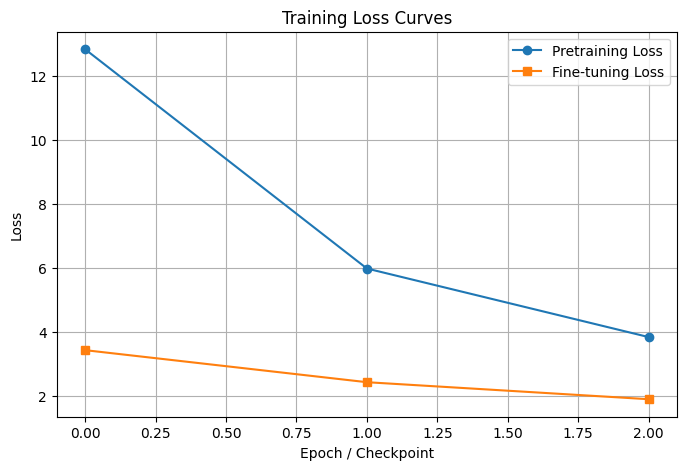

Saved: /content/drive/MyDrive/gpt-from-scratch/results/plots/loss_curves.png


In [ ]:
import matplotlib.pyplot as plt

# example values — replace with your real ones
pretrain_losses = [12.8301,5.9778, 3.8353]
finetune_losses = [3.4271,2.4261,1.8942]


plt.figure(figsize=(8, 5))
plt.plot(pretrain_losses, marker="o", label="Pretraining Loss")
plt.plot(range(len(finetune_losses)), finetune_losses, marker="s", label="Fine-tuning Loss")
plt.xlabel("Epoch / Checkpoint")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)

save_path = f"{plots_dir}/loss_curves.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

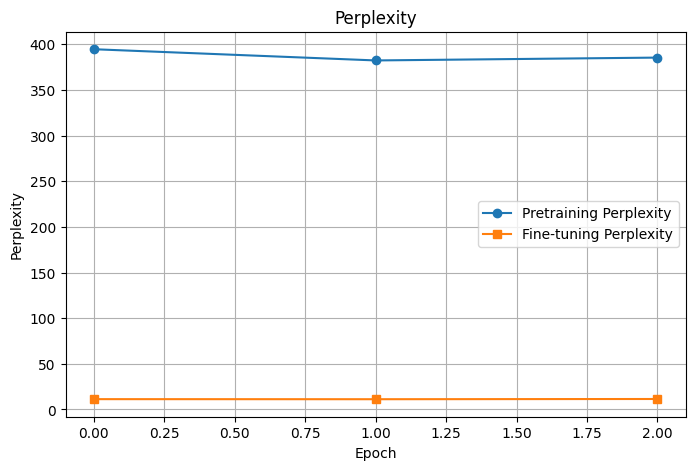

Saved: /content/drive/MyDrive/gpt-from-scratch/results/plots/perplexity.png


In [ ]:
import matplotlib.pyplot as plt

# example values — replace with your real ones
pretrain_ppl = [394.57,382.28,385.40]
finetune_ppl = [11.32,11.24,11.49]

plt.figure(figsize=(8, 5))
plt.plot(pretrain_ppl, marker="o", label="Pretraining Perplexity")
plt.plot(range(len(finetune_ppl)), finetune_ppl, marker="s", label="Fine-tuning Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity")
plt.legend()
plt.grid(True)

save_path = f"{plots_dir}/perplexity.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)